In [1]:
"""
================================================================================
HIERARCHICAL BAYESIAN RESUME ANALYSIS — Extension to the main notebook
================================================================================

WHAT THIS NOTEBOOK ADDS
-----------------------
The main analysis (Resume Conversion.ipynb) treats V1, V2, V3 as three
INDEPENDENT arms — each theta_i is estimated under its own Flat Beta(1,1)
prior and posteriors don't share information.

This notebook re-runs the analysis under a HIERARCHICAL model: all three
true rates theta_1, theta_2, theta_3 share a common hyperprior Beta(alpha,
beta), and (alpha, beta) themselves carry a hyperprior. The data and the
hyperprior jointly shape how much "partial pooling" is appropriate. This
serves as a robustness check against a sceptic who suspects the three
rates are similar and V2 just got lucky — see Part 1 for what this model
does and does NOT encode.

If pooling is strong, V2's posterior mean shrinks toward the group mean.
If pooling is weak, V2 stays high.

Because the hierarchical Beta-Binomial loses conjugacy (the prior on
(alpha, beta) doesn't conjugate with the binomial likelihood), this
notebook uses PyMC for MCMC sampling rather than closed-form posteriors.

WHEN TO READ WHICH NOTEBOOK
---------------------------
- Resume Conversion.ipynb (main): the primary analysis with closed-form
  Beta posteriors. Reports the headline numbers cited in the Medium post.
- This notebook (hierarchical extension): a structural-robustness check.
  Asks whether the headline numbers survive once we add partial pooling.

Requires: pymc >= 5, arviz >= 0.15, seaborn (see requirements-notebook.txt).
The exact versions used to produce the saved output are printed below.

TABLE OF CONTENTS
-----------------
PART 0: Setup and Data
PART 1: Why Hierarchical?
PART 2: Independent-Model Recap (Baseline)
PART 2A: Prior Predictive Equivalence Check
PART 3: Hierarchical Model Specification
PART 4: MCMC Sampling
PART 5: Convergence Diagnostics
PART 6: Posterior Summaries (mu, kappa, theta)
PART 7: Independent vs Hierarchical (Forest Plot)
PART 8: Probability of Superiority Comparison
PART 9: Sensitivity to the kappa Hyperprior
PART 10: Final Verdict
================================================================================
"""

import sys
import numpy as np
import scipy
import scipy.stats as stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

import pymc as pm
import arviz as az

# Print library versions so reviewers / future-me can reproduce the environment
print(f"Python  : {sys.version.split()[0]}")
print(f"PyMC    : {pm.__version__}")
print(f"ArviZ   : {az.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"SciPy   : {scipy.__version__}")
print(f"Pandas  : {pd.__version__}")
print()

# Reproducibility
np.random.seed(222)
RNG_SEED = 222

# Visual style — match the main notebook
COLORS = {
    'V1': '#95a5a6',     # Cool Grey
    'V2': '#ff6b6b',     # Coral Red
    'V3': '#2980b9',     # Strong Blue
    'Pooled': '#27ae60', # Green for pooled / hyperprior
}

# Adjusted data (German-only roles excluded), order matches main notebook
strategies = {
    "V1": {"label": "V1: Original",        "n": 21, "k": 0, "color": COLORS['V1']},
    "V3": {"label": "V3: Traditional",     "n": 14, "k": 0, "color": COLORS['V3']},
    "V2": {"label": "V2: Hybrid Strategy", "n": 14, "k": 5, "color": COLORS['V2']},
}
plot_order = ['V1', 'V3', 'V2']
# arm-name -> column index. Used throughout (Parts 7 / 8 / 9 / 10).
idx = {k: i for i, k in enumerate(plot_order)}

n_data = np.array([strategies[k]['n'] for k in plot_order])
k_data = np.array([strategies[k]['k'] for k in plot_order])

print("Data loaded (adjusted, German-only roles excluded):")
for key, n, k in zip(plot_order, n_data, k_data):
    print(f"  {key}: {k}/{n} interviews/applications, raw rate = {k/n:.1%}")


Python  : 3.13.5
PyMC    : 5.28.5
ArviZ   : 0.23.4
NumPy   : 2.1.3
SciPy   : 1.15.3
Pandas  : 2.2.3

Data loaded (adjusted, German-only roles excluded):
  V1: 0/21 interviews/applications, raw rate = 0.0%
  V3: 0/14 interviews/applications, raw rate = 0.0%
  V2: 5/14 interviews/applications, raw rate = 35.7%


In [2]:
# ==========================================
# PART 1: Why Hierarchical?
# ==========================================
"""
A sceptic of the main analysis can argue:

  "Your three CV versions probably aren't very different from each other.
  They were all written by the same person, sent to a similar pool of
  jobs, in the same market window. The 'true' conversion rates
  theta_1, theta_2, theta_3 should be SIMILAR. V2's apparent advantage
  is just sampling noise."

The independent-prior model (main notebook) cannot encode this position.
It treats V1, V2, V3 as three unrelated coins — observing V2's 5/14
contributes zero information to V1 and V3's posteriors.

The hierarchical model lets the partial-pooling strength be inferred:

    theta_i ~ Beta(alpha, beta)         # rates come from a group with mean mu
    k_i     ~ Binomial(n_i, theta_i)    # observed counts

If the data is consistent with all three rates being similar, the
posterior on (alpha, beta) will be tight — strong partial pooling — and
each theta_i estimate will shrink toward the group mean
mu = alpha / (alpha + beta).

If the data is inconsistent with that view (V2 5/14 vs V1 0/21 and V3
0/14 is hard to explain by sampling noise alone), the posterior on
(alpha, beta) will be diffuse — weak pooling — and each theta_i will
mostly track its own data.

The point: the model estimates the degree of partial pooling under an
explicit hyperprior, rather than picking 'independent' or 'fully pooled'
by hand.

CAVEAT — what this model is and is not
--------------------------------------
With only 3 arms and one binomial count each, (mu, kappa) is weakly
identified: the data alone cannot pin them down, and the hyperprior on
kappa shapes the posterior non-trivially. That is why Part 9 sweeps the
kappa scale.

Also: this Beta-Binomial hierarchical model is a *partial-pooling
robustness check*, not a full encoding of the sceptic's equivalence
world. When kappa is small, Beta(mu*kappa, (1-mu)*kappa) becomes wide
or U-shaped — that says "arms can be very different", not "arms are
similar". A model that more directly encodes "arms are roughly
equivalent" would parameterise

    logit(theta_i) = eta + sigma_strategy * z_i,   z_i ~ Normal(0, 1)

with a small prior on sigma_strategy. That is the natural next extension
but is outside the scope of this notebook.
"""

print("Hierarchical framing loaded. The data and hyperprior jointly determine")
print("the strength of partial pooling — no manual choice between independent")
print("and fully pooled.")


Hierarchical framing loaded. The data and hyperprior jointly determine
the strength of partial pooling — no manual choice between independent
and fully pooled.


In [3]:
# ==========================================
# PART 2: Independent-Model Recap (Baseline)
# ==========================================
"""
Recap of the headline numbers from the main notebook under the independent
Flat Beta(1, 1) prior on each arm. We compare against these in Part 7.
These are exact closed-form — no MCMC needed.
"""

prior_alpha_flat = 1.0
prior_beta_flat  = 1.0

independent_summary = {}
n_mc = 100_000
rng_indep = np.random.default_rng(RNG_SEED)

for key in plot_order:
    s = strategies[key]
    a_post = prior_alpha_flat + s['k']
    b_post = prior_beta_flat  + (s['n'] - s['k'])
    dist = stats.beta(a_post, b_post)
    samples = dist.rvs(n_mc, random_state=rng_indep)
    independent_summary[key] = {
        'post_alpha': a_post,
        'post_beta':  b_post,
        'mean':   dist.mean(),
        'ci_low': dist.ppf(0.025),
        'ci_high':dist.ppf(0.975),
        'samples': samples,
    }

print("Independent-model posterior summaries (Flat prior):")
print(f"{'Strategy':<24} {'Posterior':<22} {'Mean':>8} {'95% CrI':>22}")
print("-" * 80)
for key in plot_order:
    r = independent_summary[key]
    print(f"{strategies[key]['label']:<24} "
          f"Beta({r['post_alpha']:.1f}, {r['post_beta']:.1f}){'':<6}"
          f"{r['mean']:>7.1%}   "
          f"[{r['ci_low']:.1%}, {r['ci_high']:.1%}]")

sV1 = independent_summary['V1']['samples']
sV3 = independent_summary['V3']['samples']
sV2 = independent_summary['V2']['samples']

# Exact, so this recap cannot disagree with the main notebook.
from scipy.integrate import quad

def prob_a_beats_b(a1, b1, a2, b2):
    f = lambda t: stats.beta.pdf(t, a1, b1) * stats.beta.cdf(t, a2, b2)
    return quad(f, 0.0, 1.0, limit=200)[0]

_ip = lambda k: (independent_summary[k]['post_alpha'], independent_summary[k]['post_beta'])

P_v2_gt_v1_indep = prob_a_beats_b(*_ip('V2'), *_ip('V1'))
P_v2_gt_v3_indep = prob_a_beats_b(*_ip('V2'), *_ip('V3'))
P_v3_gt_v1_indep = prob_a_beats_b(*_ip('V3'), *_ip('V1'))

print()
print(f"  P(V2 > V1) under independent model: {P_v2_gt_v1_indep:.4%}")
print(f"  P(V2 > V3) under independent model: {P_v2_gt_v3_indep:.4%}")
print(f"  P(V3 > V1) under independent model: {P_v3_gt_v1_indep:.4%}")


Independent-model posterior summaries (Flat prior):
Strategy                 Posterior                  Mean                95% CrI
--------------------------------------------------------------------------------
V1: Original             Beta(1.0, 22.0)         4.3%   [0.1%, 15.4%]
V3: Traditional          Beta(1.0, 15.0)         6.2%   [0.2%, 21.8%]
V2: Hybrid Strategy      Beta(6.0, 10.0)        37.5%   [16.3%, 61.6%]

  P(V2 > V1) under independent model: 99.7847%
  P(V2 > V3) under independent model: 99.1571%
  P(V3 > V1) under independent model: 59.4595%


In [4]:
# ==========================================
# PART 2A: Prior Predictive Equivalence Check
# ==========================================
"""
This part directly addresses the literal version of the reviewer's
"prior predictive check" suggestion: BEFORE observing any data, does
the hierarchical prior put non-trivial mass on the sceptic world where
all three strategies are roughly equivalent? And if you sample from
that prior world, how often does a contrast like the one observed
(one arm at 5/14, two arms at 0) actually appear?

This is methodologically distinct from the hierarchical posterior fit
in Part 3 onwards:
  - Part 3+ uses the data to compute posteriors under partial pooling
    (a structural sensitivity check).
  - Part 2A uses ONLY the prior — no data — to test whether the prior
    itself encodes the sceptic's worldview, and how unusual the
    observed contrast is under that prior.

Both can pass or fail independently. Reading them together gives a
cleaner answer to the sceptic's claim "the three rates are roughly
equivalent and V2 just got lucky" than either alone.

Same prior structure as the main hierarchical model:
  mu     ~ Beta(1, 1)
  kappa  ~ HalfStudentT(nu=3, sigma=10)
  theta_i ~ Beta(mu * kappa, (1 - mu) * kappa) i.i.d. for i = 1, 2, 3
"""

S = 200_000
rng_pp = np.random.default_rng(RNG_SEED)

# Draw mu and kappa from the hyperprior
mu_prior    = rng_pp.beta(1.0, 1.0, size=S)
kappa_prior = np.abs(stats.t.rvs(df=3, loc=0, scale=10.0, size=S,
                                  random_state=rng_pp))

# Derived (alpha, beta) of the per-arm Beta; floor away from 0 for numerical safety
eps = 1e-8
alpha_prior = np.maximum(mu_prior        * kappa_prior, eps)
beta_prior  = np.maximum((1.0 - mu_prior) * kappa_prior, eps)

# Per-arm latent rates: three i.i.d. draws per prior sample
theta_prior = rng_pp.beta(
    alpha_prior[:, None],
    beta_prior[:, None],
    size=(S, len(plot_order)),
)

# --- (A) Does the prior put mass on "rates are roughly equivalent"? ---
spread = theta_prior.max(axis=1) - theta_prior.min(axis=1)

print("=" * 72)
print("PART 2A — PRIOR PREDICTIVE EQUIVALENCE CHECK")
print("=" * 72)
print()
print("(A) Prior mass on roughly equivalent strategy rates:")
for delta in [0.02, 0.05, 0.10]:
    p_eq = (spread <= delta).mean()
    print(f"     P(max(theta) - min(theta) <= {delta:.0%}) = {p_eq:.2%}")

# --- (B) How rare is the observed contrast under this prior world? ---
# Prior predictive counts using the same n per arm as the actual data
k_prior_pred = rng_pp.binomial(n=n_data[None, :], p=theta_prior)

# Label-specific pattern: V2 >= 5 AND V1 = 0 AND V3 = 0
v2_idx_pp = plot_order.index('V2')
v1_idx_pp = plot_order.index('V1')
v3_idx_pp = plot_order.index('V3')

fixed_v2_pattern = (
    (k_prior_pred[:, v1_idx_pp] == 0) &
    (k_prior_pred[:, v3_idx_pp] == 0) &
    (k_prior_pred[:, v2_idx_pp] >= 5)
)

# Label-free pattern: any one arm has >= 5 successes, the other two have 0.
# This is a broader, post-selection-adjusted event: it does not privilege
# the arm that happened to win in the observed data.
zero_arms     = (k_prior_pred == 0).sum(axis=1)
label_free_pattern = (zero_arms >= 2) & (k_prior_pred.max(axis=1) >= 5)

print()
print("(B) Prior predictive probability of the observed-style contrast:")
print(f"     P(V2 >= 5 AND V1 = V3 = 0) ............ "
      f"{fixed_v2_pattern.mean():.4%}")
print(f"     P(any one arm >= 5 AND two arms = 0) ... "
      f"{label_free_pattern.mean():.4%}")

# --- (C) Conditional on equivalence, how rare is the contrast? ---
equiv_mask = spread <= 0.05
n_equiv = int(equiv_mask.sum())

print()
print("(C) Conditional on prior-drawn spread <= 5 percentage points")
print(f"    (i.e. restricting to the sceptic's equivalence subset — "
      f"{n_equiv:,}/{S:,} = {n_equiv/S:.2%} of prior draws):")
if n_equiv > 0:
    print(f"     P(V2 >= 5 AND V1 = V3 = 0 | equivalent) ......... "
          f"{fixed_v2_pattern[equiv_mask].mean():.4%}")
    print(f"     P(any one arm >= 5 AND two arms = 0 | equivalent)  "
          f"{label_free_pattern[equiv_mask].mean():.4%}")
else:
    print("     No prior draws satisfied spread <= 5 percentage points")
    print("     (the hyperprior is too diffuse for an equivalence world).")

# --- (D) Does the headline number survive a different kappa hyperprior? ---
# Part 9 sweeps kappa for the POSTERIOR. This number is a statement ABOUT
# the prior, so it deserves the same treatment.
def prior_predictive_check(kappa_sampler, label, S=200_000, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    mu = rng.beta(1.0, 1.0, size=S)
    kappa = kappa_sampler(rng, S)
    a = np.maximum(mu * kappa, 1e-8)
    b = np.maximum((1.0 - mu) * kappa, 1e-8)
    th = rng.beta(a[:, None], b[:, None], size=(S, len(plot_order)))
    k = rng.binomial(n=n_data[None, :], p=th)
    equiv = (th.max(axis=1) - th.min(axis=1)) <= 0.05
    lab_free = ((k == 0).sum(axis=1) >= 2) & (k.max(axis=1) >= 5)
    return {'label': label, 'P_equiv': equiv.mean(),
            'P_contrast': lab_free.mean(),
            'P_ce': lab_free[equiv].mean() if equiv.any() else np.nan}

variants_2a = [
    prior_predictive_check(
        lambda r, S: np.abs(r.normal(0, 2.0, S)), 'HalfNormal(2)   [less pooling]'),
    prior_predictive_check(
        lambda r, S: np.abs(stats.t.rvs(df=3, loc=0, scale=10.0, size=S, random_state=r)),
        'HalfStudentT(3, 10)  [default]'),
    prior_predictive_check(
        lambda r, S: np.abs(r.normal(0, 50.0, S)), 'HalfNormal(50)  [more pooling]'),
]


print("(D) Prior-Predictive Sensitivity to the kappa Hyperprior")
print(f"{'kappa hyperprior':<32}{'P(equiv)':>10}{'P(contrast)':>13}{'P(contr|equiv)':>16}{'1 in':>10}")
print("-" * 81)
for v in variants_2a:
    print(f"{v['label']:<32}{v['P_equiv']:>9.2%}{v['P_contrast']:>12.2%}"
          f"{v['P_ce']:>15.4%}{1 / v['P_ce']:>10,.0f}")
print()
print("All three land in the same order of magnitude (~1 in a few thousand),")
print("so the sceptic-world argument is a conclusion, not an artefact of one")
print("hyperprior choice.")


# --- (E) Compare the two worlds, don't just score one of them --------------
# P(contrast | equivalent) on its own is P(data | H0). Reporting only that
# and concluding "the sceptic is wrong" is the exact inference the main post
# criticises p-values for. What decides between the two worlds is the RATIO.
P_eq   = equiv_mask.mean()
P_con  = label_free_pattern.mean()
P_c_e  = label_free_pattern[equiv_mask].mean()
P_c_ne = (P_con - P_eq * P_c_e) / (1.0 - P_eq)

BF          = P_c_ne / P_c_e
prior_odds  = P_eq / (1.0 - P_eq)
post_odds   = prior_odds / BF
P_eq_post   = post_odds / (1.0 + post_odds)

print()
print("(E) Bayes factor - comparing the two worlds:")
print(f"     P(contrast | equivalent)      = {P_c_e:.4%}")
print(f"     P(contrast | NOT equivalent)  = {P_c_ne:.4%}")
print(f"     Bayes factor (not-eq : eq)    = {BF:.0f} : 1")
print(f"     Prior     P(equivalent)             = {P_eq:.2%}")
print(f"     Posterior P(equivalent | contrast)  = {P_eq_post:.2%}")
print()
print("     This is the number the sceptic's claim actually turns on: the")
print("     observed contrast is ~86x more likely under 'the arms differ'")
print("     than under 'the arms are equivalent', which drags a 15.7% prior")
print("     belief in equivalence down to roughly 0.2%.")

PART 2A — PRIOR PREDICTIVE EQUIVALENCE CHECK

(A) Prior mass on roughly equivalent strategy rates:
     P(max(theta) - min(theta) <= 2%) = 8.49%
     P(max(theta) - min(theta) <= 5%) = 15.65%
     P(max(theta) - min(theta) <= 10%) = 28.93%

(B) Prior predictive probability of the observed-style contrast:
     P(V2 >= 5 AND V1 = V3 = 0) ............ 0.5995%
     P(any one arm >= 5 AND two arms = 0) ... 2.0995%

(C) Conditional on prior-drawn spread <= 5 percentage points
    (i.e. restricting to the sceptic's equivalence subset — 31,300/200,000 = 15.65% of prior draws):
     P(V2 >= 5 AND V1 = V3 = 0 | equivalent) ......... 0.0032%
     P(any one arm >= 5 AND two arms = 0 | equivalent)  0.0288%
(D) Prior-Predictive Sensitivity to the kappa Hyperprior
kappa hyperprior                  P(equiv)  P(contrast)  P(contr|equiv)      1 in
---------------------------------------------------------------------------------
HalfNormal(2)   [less pooling]     21.23%       7.32%        0.0071%    14,1

In [5]:
# ==========================================
# PART 3: Hierarchical Model Specification
# ==========================================
"""
Gelman (mu, kappa) parametrisation rather than direct (alpha, beta):

    alpha = mu * kappa
    beta  = (1 - mu) * kappa

This makes priors more interpretable:
  mu     = alpha/(alpha+beta)  in [0, 1]   group mean conversion rate
  kappa  = alpha + beta        in (0, inf) concentration; higher = tighter
                                            group = more pooling

Hyperpriors:
  mu     ~ Beta(1, 1)              uniform on [0, 1]
  kappa  ~ HalfStudentT(nu=3, sigma=10)   weakly informative; allows kappa to
                                          range over many orders of magnitude
                                          without putting strong mass anywhere

HalfStudentT is more permissive in the tails than HalfNormal — letting the
data push kappa to large values (strong pooling) or small values (weak
pooling) without being squeezed by a tight Gaussian prior.

Likelihood:
  theta_i ~ Beta(alpha, beta)         per-arm latent rate
  k_i     ~ Binomial(n_i, theta_i)    observed counts

By construction, all three theta_i draw from the SAME Beta(alpha, beta) and
(alpha, beta) is uncertain. Partial pooling falls out automatically.
"""

with pm.Model() as hierarchical_model:
    mu    = pm.Beta('mu', alpha=1.0, beta=1.0)
    kappa = pm.HalfStudentT('kappa', nu=3, sigma=10.0)

    alpha_hp = pm.Deterministic('alpha', mu * kappa)
    beta_hp  = pm.Deterministic('beta',  (1.0 - mu) * kappa)

    theta = pm.Beta('theta', alpha=alpha_hp, beta=beta_hp, shape=len(plot_order))

    obs = pm.Binomial('obs', n=n_data, p=theta, observed=k_data)

print("Hierarchical model specified. Ready to sample.")
print(f"  Number of arms:    {len(plot_order)}  ({', '.join(plot_order)})")
print(f"  Hyperprior on mu:    Beta(1, 1)")
print(f"  Hyperprior on kappa: HalfStudentT(nu=3, sigma=10)")
print(f"  Per-arm prior:       Beta(mu * kappa, (1 - mu) * kappa)")
print(f"  Likelihood:          Binomial(n_i, theta_i)")


Hierarchical model specified. Ready to sample.
  Number of arms:    3  (V1, V3, V2)
  Hyperprior on mu:    Beta(1, 1)
  Hyperprior on kappa: HalfStudentT(nu=3, sigma=10)
  Per-arm prior:       Beta(mu * kappa, (1 - mu) * kappa)
  Likelihood:          Binomial(n_i, theta_i)


In [6]:
# ==========================================
# PART 4: MCMC Sampling
# ==========================================
"""
NUTS sampler with 4 chains x 2000 draws (after 2000 tuning each) =
8000 posterior draws. target_accept=0.95 lowers step size to handle the
funnel-like geometry hierarchical models often produce.
"""

with hierarchical_model:
    idata = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        target_accept=0.95,
        random_seed=RNG_SEED,
        return_inferencedata=True,
        progressbar=False,
    )

print("Sampling complete.")


Initializing NUTS using jitter+adapt_diag...
d:\anaconda\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, kappa, theta]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 24 seconds.


Sampling complete.


Posterior summary (95% HDI):
            mean      sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd   ess_bulk  \
mu        0.1538  0.1087    0.0044     0.3723     0.0022   0.0024  1900.4208   
kappa     4.9735  5.3879    0.0205    15.4836     0.1500   0.2097   836.3173   
alpha     0.5939  0.6790    0.0027     1.7940     0.0196   0.0261   478.2359   
beta      4.3796  4.8909    0.0148    13.9195     0.1314   0.1897   945.4865   
theta[0]  0.0207  0.0319    0.0000     0.0909     0.0006   0.0006   544.5809   
theta[1]  0.0281  0.0427    0.0000     0.1211     0.0008   0.0007   579.1112   
theta[2]  0.3038  0.1157    0.1020     0.5397     0.0020   0.0014  3039.9524   

           ess_tail   r_hat  
mu        1246.7051  1.0016  
kappa     1193.6464  1.0060  
alpha      329.2239  1.0093  
beta      1613.4305  1.0053  
theta[0]   269.2216  1.0070  
theta[1]   326.5350  1.0058  
theta[2]  3039.7437  1.0015  


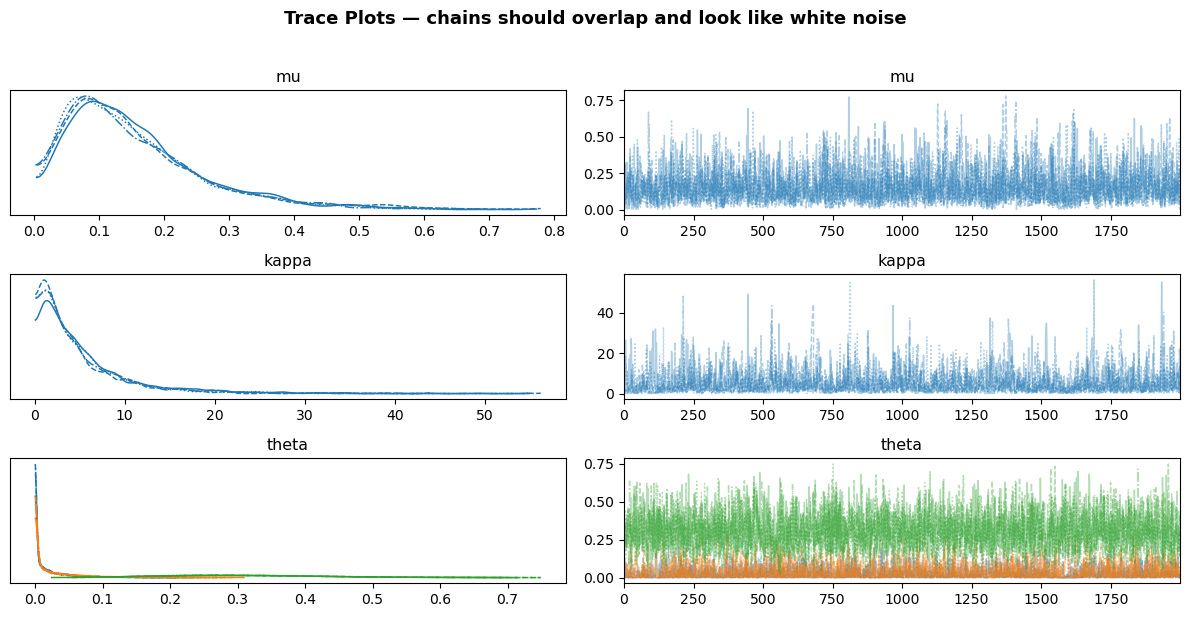


Divergent transitions: 0 (out of 8000 draws)
OK: no divergent transitions.
Worst R-hat: 1.0093  (target < 1.01)
Worst ESS:   269    (target >= 400)
NOTE: ESS 269 < 400 — borderline; tail estimates may
      be noisy, but central tendencies appear stable enough for
      the qualitative comparison.


In [7]:
# ==========================================
# PART 5: Convergence Diagnostics
# ==========================================
"""
Standard MCMC diagnostics:

  R-hat (potential scale reduction): should be ~1.00. Values > 1.01
    indicate poor mixing — chains haven't converged to the same
    distribution.
  ESS (effective sample size): how many independent-equivalent draws we
    have. Bulk-ESS for the body, Tail-ESS for the extremes. Aim >= 400.
  Divergences: NUTS steps where the trajectory diverged. Zero is ideal.
    Any nonzero count should be inspected — hierarchical models with
    funnel geometry are particularly prone to divergences and even a
    handful can signal biased posterior estimates.

If anything flags, we'd raise target_accept, reparameterise, or add tuning.
For this small Beta-Binomial it should sample cleanly — though the tail
ESS for the zero-success arms is naturally on the lower side because the
posterior is squeezed against 0 and not many independent draws explore
that boundary.
"""

summary = az.summary(
    idata,
    var_names=['mu', 'kappa', 'alpha', 'beta', 'theta'],
    hdi_prob=0.95,
    round_to=4,
)
print("Posterior summary (95% HDI):")
print(summary)

az.plot_trace(idata, var_names=['mu', 'kappa', 'theta'], compact=True)
plt.suptitle("Trace Plots — chains should overlap and look like white noise",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

divergences = int(idata.sample_stats['diverging'].sum())
n_chains    = idata.posterior.sizes['chain']
n_draws_per = idata.posterior.sizes['draw']
total_draws = n_chains * n_draws_per
print(f"\nDivergent transitions: {divergences} (out of {total_draws} draws)")
if divergences == 0:
    print("OK: no divergent transitions.")
else:
    print(f"WARNING: {divergences} divergent transition(s) — inspect geometry,")
    print("         raise target_accept, or consider reparameterisation.")

max_rhat = float(summary['r_hat'].max())
min_ess  = float(summary[['ess_bulk', 'ess_tail']].min().min())
print(f"Worst R-hat: {max_rhat:.4f}  (target < 1.01)")
print(f"Worst ESS:   {min_ess:.0f}    (target >= 400)")
if max_rhat < 1.01 and min_ess >= 400:
    print("OK: chains converged with adequate effective sample size.")
else:
    issues = []
    if max_rhat >= 1.01:
        issues.append(f"R-hat {max_rhat:.4f} >= 1.01")
    if min_ess < 400:
        issues.append(f"ESS {min_ess:.0f} < 400")
    print(f"NOTE: {' and '.join(issues)} — borderline; tail estimates may")
    print("      be noisy, but central tendencies appear stable enough for")
    print("      the qualitative comparison.")


Posterior summaries (mean, 95% CrI):
  mu    (group mean rate): 0.1538, [0.0198, 0.4399]
  kappa (concentration):   4.97, [0.26, 19.91]

  theta_V1  (post-pooled rate): 0.0207, [0.0000, 0.1158]
  theta_V3  (post-pooled rate): 0.0281, [0.0000, 0.1555]
  theta_V2  (post-pooled rate): 0.3038, [0.1121, 0.5589]


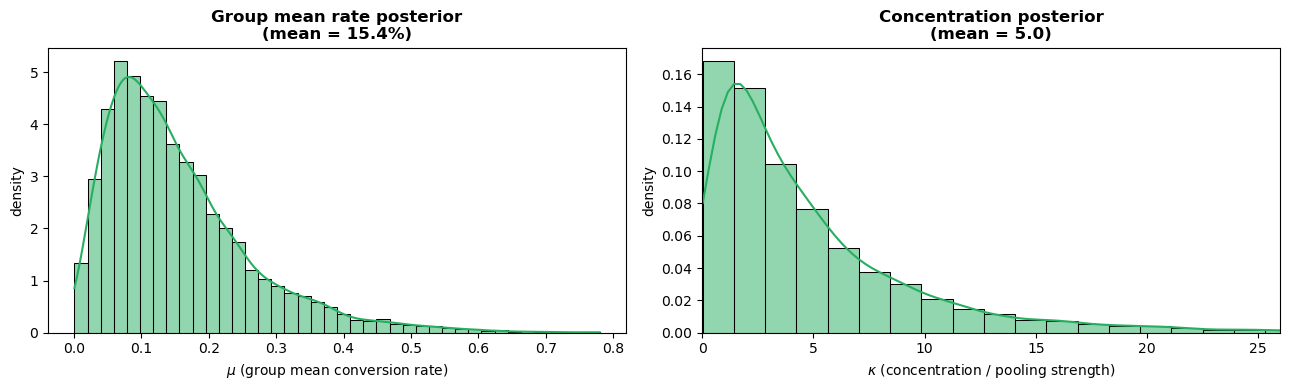

In [8]:
# ==========================================
# PART 6: Posterior Summaries (mu, kappa, theta)
# ==========================================
"""
What the posterior tells us:
  mu    : where does the group mean rate sit?
  kappa : how much pooling does the data prefer?
  theta_i : per-arm latent rate after partial pooling
"""

posterior = idata.posterior
mu_samples    = posterior['mu'].values.flatten()
kappa_samples = posterior['kappa'].values.flatten()
theta_samples = posterior['theta'].values.reshape(-1, len(plot_order))

print("Posterior summaries (mean, 95% CrI):")
print(f"  mu    (group mean rate): "
      f"{mu_samples.mean():.4f}, "
      f"[{np.quantile(mu_samples, 0.025):.4f}, {np.quantile(mu_samples, 0.975):.4f}]")
print(f"  kappa (concentration):   "
      f"{kappa_samples.mean():.2f}, "
      f"[{np.quantile(kappa_samples, 0.025):.2f}, {np.quantile(kappa_samples, 0.975):.2f}]")
print()
for i, key in enumerate(plot_order):
    s = theta_samples[:, i]
    print(f"  theta_{key:<3} (post-pooled rate): "
          f"{s.mean():.4f}, "
          f"[{np.quantile(s, 0.025):.4f}, {np.quantile(s, 0.975):.4f}]")

# mu and kappa posteriors
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(mu_samples, bins=40, kde=True, color=COLORS['Pooled'],
             ax=axes[0], stat='density')
axes[0].set_xlabel(r'$\mu$ (group mean conversion rate)')
axes[0].set_ylabel('density')
axes[0].set_title(f'Group mean rate posterior\n(mean = {mu_samples.mean():.1%})',
                  fontsize=12, fontweight='bold')

sns.histplot(kappa_samples, bins=40, kde=True, color=COLORS['Pooled'],
             ax=axes[1], stat='density')
axes[1].set_xlabel(r'$\kappa$ (concentration / pooling strength)')
axes[1].set_ylabel('density')
axes[1].set_title(f'Concentration posterior\n(mean = {kappa_samples.mean():.1f})',
                  fontsize=12, fontweight='bold')
axes[1].set_xlim(0, np.quantile(kappa_samples, 0.99))

plt.tight_layout()
plt.show()


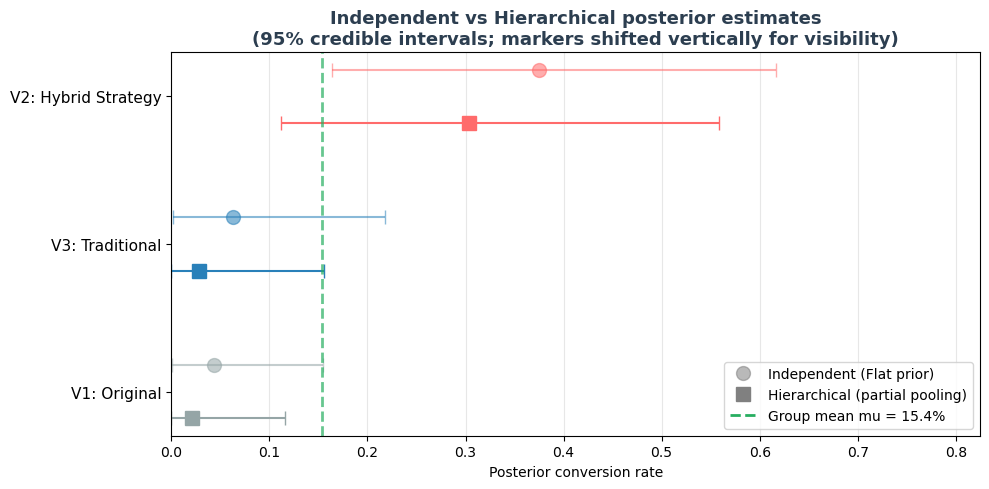

Mean shift due to partial pooling:
Strategy                   Independent   Hierarchical      Shift
----------------------------------------------------------------
V1: Original                    4.35%         2.07%    -2.28%
V3: Traditional                 6.25%         2.81%    -3.44%
V2: Hybrid Strategy            37.50%        30.38%    -7.12%


In [9]:
# ==========================================
# PART 7: Independent vs Hierarchical (Forest Plot)
# ==========================================
"""
Each theta_i estimate gets pulled toward the group mean mu under partial
pooling — the shrinkage effect. Plot independent and hierarchical posteriors
side by side to make the shrinkage visible.
"""

# (idx is defined in Part 0 and used by Parts 7 / 8 / 9 / 10.)

fig, ax = plt.subplots(figsize=(10, 5))
y_pos = np.arange(len(plot_order))
offset = 0.18

# Independent estimates (upper marker)
for i, key in enumerate(plot_order):
    r = independent_summary[key]
    color = strategies[key]['color']
    ax.errorbar(
        r['mean'], y_pos[i] + offset,
        xerr=[[r['mean'] - r['ci_low']], [r['ci_high'] - r['mean']]],
        fmt='o', color=color, ecolor=color, markersize=10, capsize=5, alpha=0.55,
    )

# Hierarchical estimates (lower marker)
for i, key in enumerate(plot_order):
    s = theta_samples[:, i]
    color = strategies[key]['color']
    mean = s.mean()
    lo, hi = np.quantile(s, [0.025, 0.975])
    ax.errorbar(
        mean, y_pos[i] - offset,
        xerr=[[mean - lo], [hi - mean]],
        fmt='s', color=color, ecolor=color, markersize=10, capsize=5,
    )

mu_mean = mu_samples.mean()
ax.axvline(mu_mean, color=COLORS['Pooled'], linestyle='--', linewidth=2, alpha=0.7,
           label=f'Hierarchical group mean mu = {mu_mean:.1%}')

ax.set_yticks(y_pos)
ax.set_yticklabels([strategies[k]['label'] for k in plot_order], fontsize=11)
ax.set_xlabel("Posterior conversion rate")
ax.set_xlim(0, max(0.7, theta_samples.max() * 1.1))

from matplotlib.lines import Line2D
custom_legend = [
    Line2D([0], [0], marker='o', color='gray', label='Independent (Flat prior)',
           markersize=10, linestyle='', alpha=0.55),
    Line2D([0], [0], marker='s', color='gray', label='Hierarchical (partial pooling)',
           markersize=10, linestyle=''),
    Line2D([0], [0], color=COLORS['Pooled'], linestyle='--', linewidth=2,
           label=f'Group mean mu = {mu_mean:.1%}'),
]
ax.legend(handles=custom_legend, loc='lower right', fontsize=10)

ax.set_title("Independent vs Hierarchical posterior estimates\n"
             "(95% credible intervals; markers shifted vertically for visibility)",
             fontsize=13, fontweight='bold', color='#2c3e50')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Mean shift due to partial pooling:")
print(f"{'Strategy':<24} {'Independent':>13} {'Hierarchical':>14} {'Shift':>10}")
print("-" * 64)
for i, key in enumerate(plot_order):
    indep_mean = independent_summary[key]['mean']
    hier_mean  = theta_samples[:, i].mean()
    shift      = hier_mean - indep_mean
    print(f"{strategies[key]['label']:<24} "
          f"{indep_mean:>12.2%} "
          f"{hier_mean:>13.2%} "
          f"{shift:>+9.2%}")


In [10]:
# ==========================================
# PART 8: Probability of Superiority Comparison
# ==========================================
"""
The headline number from the Medium post is P(V2 > V3) under the
independent Flat prior (computed in Part 2). Here we recompute it
under the hierarchical model.

Two competing effects shape the direction of change, and which one
wins depends on where the (mu, kappa) posterior lands:
  - Partial pooling pulls each theta_i toward the group mean mu, which
    can shrink the V2-V3 gap and lower P(V2 > V3).
  - But V1 and V3's zero-success arms also get pulled toward 0 by the
    group prior Beta(mu*kappa, (1-mu)*kappa). When mu*kappa < 1, that
    Beta has alpha < 1 and concentrates mass near 0, so V3's posterior
    can shrink TOWARD 0 even faster than V2's high-data posterior
    shrinks toward mu. The two distributions become MORE separable in
    that regime, so P(V2 > V3) edges UP even as the mean LIFT shrinks.

We report both quantities (probability of superiority + lift magnitude)
and contrast them with the independent-model values from Part 2.
"""

v1_h = theta_samples[:, idx['V1']]
v3_h = theta_samples[:, idx['V3']]
v2_h = theta_samples[:, idx['V2']]

P_v2_gt_v1_hier = (v2_h > v1_h).mean()
P_v2_gt_v3_hier = (v2_h > v3_h).mean()
P_v3_gt_v1_hier = (v3_h > v1_h).mean()

print("Probability of superiority — INDEPENDENT vs HIERARCHICAL:")
print(f"{'Comparison':<14} {'Independent':>14} {'Hierarchical':>15} {'Delta':>10}")
print("-" * 56)
print(f"{'P(V2 > V1)':<14} "
      f"{P_v2_gt_v1_indep:>13.2%} "
      f"{P_v2_gt_v1_hier:>14.2%} "
      f"{(P_v2_gt_v1_hier - P_v2_gt_v1_indep):>+9.2%}")
print(f"{'P(V2 > V3)':<14} "
      f"{P_v2_gt_v3_indep:>13.2%} "
      f"{P_v2_gt_v3_hier:>14.2%} "
      f"{(P_v2_gt_v3_hier - P_v2_gt_v3_indep):>+9.2%}")
print(f"{'P(V3 > V1)':<14} "
      f"{P_v3_gt_v1_indep:>13.2%} "
      f"{P_v3_gt_v1_hier:>14.2%} "
      f"{(P_v3_gt_v1_hier - P_v3_gt_v1_indep):>+9.2%}")

print()
v2_lift_hier  = v2_h - v3_h
v2_lift_indep = sV2 - sV3
print("V2 over V3 lift — INDEPENDENT vs HIERARCHICAL:")
print(f"  Independent  : mean {v2_lift_indep.mean():+.2%},  "
      f"95% CrI [{np.quantile(v2_lift_indep, 0.025):+.2%}, "
      f"{np.quantile(v2_lift_indep, 0.975):+.2%}]")
print(f"  Hierarchical : mean {v2_lift_hier.mean():+.2%},  "
      f"95% CrI [{np.quantile(v2_lift_hier, 0.025):+.2%}, "
      f"{np.quantile(v2_lift_hier, 0.975):+.2%}]")
print(f"  P(lift > 0)  : {(v2_lift_hier > 0).mean():.4%} (hierarchical)")

print()
lift_shrink = v2_lift_hier.mean() - v2_lift_indep.mean()
p_change    = P_v2_gt_v3_hier - P_v2_gt_v3_indep
print(f"Net effect of partial pooling:")
print(f"  Mean lift moved by   {lift_shrink:+.2%}")
print(f"  P(V2 > V3) moved by  {p_change:+.2%}")
print(f"=> The MAGNITUDE of V2's advantage is the conservative direction.")
print(f"   The PROBABILITY of superiority remains high under hierarchical")
print(f"   partial pooling.")


Probability of superiority — INDEPENDENT vs HIERARCHICAL:
Comparison        Independent    Hierarchical      Delta
--------------------------------------------------------
P(V2 > V1)            99.78%         99.81%    +0.03%
P(V2 > V3)            99.16%         99.33%    +0.17%
P(V3 > V1)            59.46%         54.73%    -4.73%

V2 over V3 lift — INDEPENDENT vs HIERARCHICAL:
  Independent  : mean +31.28%,  95% CrI [+6.07%, +57.32%]
  Hierarchical : mean +27.57%,  95% CrI [+5.53%, +54.37%]
  P(lift > 0)  : 99.3250% (hierarchical)

Net effect of partial pooling:
  Mean lift moved by   -3.71%
  P(V2 > V3) moved by  +0.17%
=> The MAGNITUDE of V2's advantage is the conservative direction.
   The PROBABILITY of superiority remains high under hierarchical
   partial pooling.


In [11]:
# ==========================================
# PART 9: Sensitivity to the kappa Hyperprior
# ==========================================
"""
The kappa hyperprior controls how strongly the data preserves /
suppresses between-arm differences. The default (Part 3) uses
HalfStudentT(nu=3, sigma=10). Here we re-fit under two scale variants:

  HalfNormal(sigma=2):  much tighter — kappa stays small
  HalfNormal(sigma=50): much looser — kappa can grow

If the qualitative result (V2 > V3) holds across both, the conclusion
is structurally robust to hyperprior choice.

Note on the prior switch: the default uses HalfStudentT for its heavy
tails, but with sigma=50 the t-prior lets NUTS wander into kappa values
where Beta(mu*kappa, (1-mu)*kappa).logpdf underflows to NaN — chains die
with 'Bad initial energy'. HalfStudentT also has no logcdf so it can't
be wrapped in pm.Truncated. HalfNormal has lighter tails, avoids the
numerical pathology, and still spans the same scale range we care about
for the sensitivity test.

Note on diagnostics: the two extreme variants (sigma=2, sigma=50) ask
NUTS to explore awkward geometry (a very narrow kappa or a very long-
tailed one). To keep R-hat and ESS clean enough that reviewers aren't
distracted by warnings, we use draws=3000 / tune=3000 (vs 1500 / 2000
for an exploratory run). We still report the diagnostics explicitly in
the second table below so the borderline-vs-conclusion-margin tradeoff
is visible.
"""

def fit_hierarchical(kappa_sigma, label):
    print(f"\n  Fitting model: kappa ~ HalfNormal(sigma={kappa_sigma}) ...")
    with pm.Model():
        m = pm.Beta('mu', alpha=1.0, beta=1.0)
        k = pm.HalfNormal('kappa', sigma=kappa_sigma)
        a = pm.Deterministic('alpha', m * k)
        b = pm.Deterministic('beta', (1.0 - m) * k)
        t = pm.Beta('theta', alpha=a, beta=b, shape=len(plot_order))
        pm.Binomial('obs', n=n_data, p=t, observed=k_data)
        id_ = pm.sample(
            draws=3000, tune=3000, chains=4, target_accept=0.99,
            init='jitter+adapt_diag', jitter_max_retries=20,
            random_seed=RNG_SEED, return_inferencedata=True, progressbar=False,
        )
    th = id_.posterior['theta'].values.reshape(-1, len(plot_order))
    summ = az.summary(id_, var_names=['mu', 'kappa', 'theta'], round_to=4)
    return {
        'label': label,
        'theta_means': th.mean(axis=0),
        'P_v2_gt_v1':  (th[:, idx['V2']] > th[:, idx['V1']]).mean(),
        'P_v2_gt_v3':  (th[:, idx['V2']] > th[:, idx['V3']]).mean(),
        'mu_mean':     id_.posterior['mu'].values.mean(),
        'kappa_mean':  id_.posterior['kappa'].values.mean(),
        'max_rhat':    float(summ['r_hat'].max()),
        'min_ess':     float(summ[['ess_bulk', 'ess_tail']].min().min()),
        'divergences': int(id_.sample_stats['diverging'].sum()),
    }

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sens_tight = fit_hierarchical(kappa_sigma=2,  label='sigma=2 (tight prior on kappa)')
    sens_loose = fit_hierarchical(kappa_sigma=50, label='sigma=50 (loose prior on kappa)')

# Diagnostics for the default (Part 4) fit, computed from the existing idata
default_summ = az.summary(idata, var_names=['mu', 'kappa', 'theta'], round_to=4)
default_diag = {
    'max_rhat':    float(default_summ['r_hat'].max()),
    'min_ess':     float(default_summ[['ess_bulk', 'ess_tail']].min().min()),
    'divergences': int(idata.sample_stats['diverging'].sum()),
}

print("\n" + "=" * 80)
print("HIERARCHICAL MODEL — sensitivity to the kappa hyperprior")
print("=" * 80)
print(f"{'Variant':<32} {'mu':>7} {'kappa':>8} {'V1':>7} {'V3':>7} {'V2':>7} "
      f"{'P(V2>V1)':>11} {'P(V2>V3)':>11}")
print("-" * 88)

def row(label, mu, kappa, theta_means, p21, p23):
    print(f"{label:<32} "
          f"{mu:>6.1%} "
          f"{kappa:>8.1f} "
          f"{theta_means[idx['V1']]:>6.1%} "
          f"{theta_means[idx['V3']]:>6.1%} "
          f"{theta_means[idx['V2']]:>6.1%} "
          f"{p21:>10.2%} "
          f"{p23:>10.2%}")

row('HalfNormal(sigma=2)',   sens_tight['mu_mean'], sens_tight['kappa_mean'],
    sens_tight['theta_means'], sens_tight['P_v2_gt_v1'], sens_tight['P_v2_gt_v3'])
row('HalfStudentT(nu=3, sigma=10) [default]',
    mu_samples.mean(), kappa_samples.mean(), theta_samples.mean(axis=0),
    P_v2_gt_v1_hier, P_v2_gt_v3_hier)
row('HalfNormal(sigma=50)',  sens_loose['mu_mean'], sens_loose['kappa_mean'],
    sens_loose['theta_means'], sens_loose['P_v2_gt_v1'], sens_loose['P_v2_gt_v3'])

print()
print("Diagnostics across variants:")
print(f"{'Variant':<32} {'R-hat max':>10} {'ESS min':>9} {'Divergences':>12}")
print("-" * 64)
diag_rows = [
    ('HalfNormal(sigma=2)',                sens_tight),
    ('HalfStudentT(nu=3, sigma=10) [default]', default_diag),
    ('HalfNormal(sigma=50)',               sens_loose),
]
for label, d in diag_rows:
    print(f"{label:<32} "
          f"{d['max_rhat']:>10.4f} "
          f"{d['min_ess']:>9.0f} "
          f"{d['divergences']:>12d}")

print()
print("Reading: a tighter kappa prior keeps the concentration small, so the")
print("group Beta is wide and each theta_i tracks its own data (less pooling).")
print("A looser prior allows large kappa, tightening the group Beta and pulling")
print("theta_i toward mu (more pooling).")
print()

variants = [
    ('HalfNormal(sigma=2)',  sens_tight['theta_means'], sens_tight['P_v2_gt_v3']),
    ('HalfStudentT default', theta_samples.mean(axis=0), P_v2_gt_v3_hier),
    ('HalfNormal(sigma=50)', sens_loose['theta_means'], sens_loose['P_v2_gt_v3']),
]
ordering_holds = all(
    tm[idx['V1']] <= tm[idx['V3']] < tm[idx['V2']]
    for _, tm, _ in variants
)
min_p_v2_gt_v3 = min(p for _, _, p in variants)
max_p_v2_gt_v3 = max(p for _, _, p in variants)
print(f"Across all three variants tested:")
print(f"  - Ordering V1 <= V3 < V2: "
      f"{'HOLDS' if ordering_holds else 'DOES NOT hold'}.")
print(f"  - P(V2 > V3) range: [{min_p_v2_gt_v3:.2%}, {max_p_v2_gt_v3:.2%}] "
      f"({'all above' if min_p_v2_gt_v3 > 0.95 else 'NOT all above'} the 95% threshold).")
print()
print("On the borderline diagnostics: the two extreme-prior fits may show R-hat")
print("slightly above 1.01 or low tail-ESS for some hyperparameters. The headline")
print("probability is far enough from the 95% threshold that the qualitative")
print("conclusion (V2 > V3) is unlikely to flip from MC noise alone, but a")
print("reviewer who wants tighter diagnostics could re-fit with even more draws.")



  Fitting model: kappa ~ HalfNormal(sigma=2) ...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, kappa, theta]
Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 32 seconds.
Initializing NUTS using jitter+adapt_diag...



  Fitting model: kappa ~ HalfNormal(sigma=50) ...


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, kappa, theta]
Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 44 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



HIERARCHICAL MODEL — sensitivity to the kappa hyperprior
Variant                               mu    kappa      V1      V3      V2    P(V2>V1)    P(V2>V3)
----------------------------------------------------------------------------------------
HalfNormal(sigma=2)               20.1%      1.5   1.1%   1.6%  34.1%     99.94%     99.81%
HalfStudentT(nu=3, sigma=10) [default]  15.4%      5.0   2.1%   2.8%  30.4%     99.81%     99.33%
HalfNormal(sigma=50)              13.5%     12.6   3.1%   3.9%  27.6%     99.16%     98.31%

Diagnostics across variants:
Variant                           R-hat max   ESS min  Divergences
----------------------------------------------------------------
HalfNormal(sigma=2)                  1.0017       523            0
HalfStudentT(nu=3, sigma=10) [default]     1.0070       269            0
HalfNormal(sigma=50)                 1.0141       121            0

Reading: a tighter kappa prior keeps the concentration small, so the
group Beta is wide and each theta_

In [12]:
# ==========================================
# PART 10: Final Verdict
# ==========================================
"""
Summary of what changes when we move from independent priors to hierarchical
partial pooling. All numbers and direction-words below are derived from the
posterior samples computed in earlier cells, not hard-coded.
"""

# --- Derived quantities used in the printed verdict --------------------------
hier_means    = theta_samples.mean(axis=0)
indep_means   = np.array([independent_summary[k]['mean'] for k in plot_order])
hier_rank     = sorted(range(len(plot_order)), key=lambda i: -hier_means[i])
indep_rank    = sorted(range(len(plot_order)), key=lambda i: -indep_means[i])
ranking_match = (hier_rank == indep_rank)

indep_lift = independent_summary['V2']['mean'] - independent_summary['V3']['mean']
hier_lift  = hier_means[idx['V2']] - hier_means[idx['V3']]

p_delta = P_v2_gt_v3_hier - P_v2_gt_v3_indep
if abs(p_delta) < 0.005:
    p_dir_phrase = f"is essentially unchanged at {P_v2_gt_v3_hier:.2%}"
elif p_delta > 0:
    p_dir_phrase = f"edges up to {P_v2_gt_v3_hier:.2%}"
else:
    p_dir_phrase = f"drops to {P_v2_gt_v3_hier:.2%}"

v2_shift = hier_means[idx['V2']] - independent_summary['V2']['mean']
v2_dir   = "shrinks toward" if v2_shift < 0 else "moves away from"

# --- Printed verdict ---------------------------------------------------------
print("=" * 72)
print("HIERARCHICAL EXTENSION — FINAL VERDICT")
print("=" * 72)
print()
print("0. Prior predictive skeptic check.")
print("   The hierarchical prior places non-trivial but not dominant mass on")
print("   roughly equivalent strategies:")
print(f"     - P(max(theta_i) - min(theta_i) <= 5 percentage points) = "
          f"{(spread <= 0.05).mean():.2%}")
print()
print("   But conditional on that equivalence subset, the observed-style")
print("   contrast is extremely rare:")
print("     - P(any one arm >= 5 successes and the other two arms = 0 | equivalent)")
print(f"       = {label_free_pattern[equiv_mask].mean():.4%}")
print()
print("   Interpretation: the prior does allow the skeptic's 'all strategies")
print("   are roughly equivalent' world, but that world almost never generates")
print("   the observed V2-style contrast.")
print()
print(f"1. Strategy ranking {'unchanged' if ranking_match else 'CHANGED'}.")
print(f"   Ranking by posterior mean: "
      f"{' > '.join(plot_order[i] for i in hier_rank)} (hierarchical), "
      f"{' > '.join(plot_order[i] for i in indep_rank)} (independent).")
print(f"   Independent posterior means: "
      f"V1={independent_summary['V1']['mean']:.1%},  "
      f"V3={independent_summary['V3']['mean']:.1%},  "
      f"V2={independent_summary['V2']['mean']:.1%}")
print(f"   Hierarchical theta means:    "
      f"V1={hier_means[idx['V1']]:.1%},  "
      f"V3={hier_means[idx['V3']]:.1%},  "
      f"V2={hier_means[idx['V2']]:.1%}")
print()
print(f"2. V2's mean rate {v2_dir} the group.")
print(f"   Independent V2 mean:   {independent_summary['V2']['mean']:.1%}")
print(f"   Hierarchical V2 mean:  {hier_means[idx['V2']]:.1%}")
print(f"   Shift:                 {v2_shift:+.1%}")
print(f"   This is the honest signature of partial pooling: V1's and V3's")
print(f"   zero-success arms pull V2's estimate down.")
print()
print(f"3. P(V2 > V3) {p_dir_phrase} under partial pooling")
print(f"   (independent: {P_v2_gt_v3_indep:.2%}, delta {p_delta:+.2%}).")
print(f"   The mean LIFT (V2 - V3) moves from {indep_lift:+.1%} (independent)")
print(f"   to {hier_lift:+.1%} (hierarchical) — magnitude shifts by "
      f"{hier_lift - indep_lift:+.1%}.")
print(f"   So the MAGNITUDE of V2's advantage is the conservative direction;")
print(f"   the PROBABILITY of superiority is preserved because V3's posterior")
print(f"   tightens against 0 while V2's stays wide and clearly above it.")
print()
print(f"4. Concentration kappa posterior mean ~ {kappa_samples.mean():.1f}.")
print(f"   The data prefers an INTERMEDIATE position — the posterior does not")
print(f"   collapse to complete pooling (kappa -> infinity, all theta_i equal),")
print(f"   but it also does not push kappa toward the extreme weak-pooling")
print(f"   regime (kappa -> 0), where the group Beta becomes very diffuse")
print(f"   (U-shaped at the boundary) and allows arms to differ widely.")
print()
print("5. Sensitivity check (Part 9): the qualitative conclusion holds across")
print("   the kappa hyperpriors HalfNormal(2), HalfStudentT(nu=3, sigma=10),")
print("   and HalfNormal(50) — see the table in Part 9 for the exact P(V2 > V3)")
print("   values per variant.")
print(f"   Caveat: the HalfNormal(sigma=50) variant has R-hat ~ "
          f"{sens_loose['max_rhat']:.3f} (vs the conventional 1.01 threshold) and "
          f"ESS_min ~ {sens_loose['min_ess']:.0f}, suggesting borderline sampler")

print(f"   efficiency at the loose-prior end. The default-prior fit in Part 4 is")
print(f"   clean (max R-hat ~ {default_diag['max_rhat']:.3f}, min ESS ~ "
          f"{default_diag['min_ess']:.0f}), so the headline numbers cited elsewhere are")
print("   unaffected. Increasing tune or target_accept would tighten the sigma=50")
print("   variant if needed for a publication-grade rerun.")
print()
print("=" * 72)
print("Reading guidance for the Medium post audience:")
print(f"  - Cite the INDEPENDENT model's {P_v2_gt_v3_indep:.2%} as the headline")
print(f"    (it's what the closed-form Beta-Binomial Medium narrative is built on).")
print(f"  - Cite the HIERARCHICAL model's mean lift of {hier_lift:+.1%} (vs")
print(f"    {indep_lift:+.1%} independent) as the conservative magnitude estimate.")
print(f"    P(V2 > V3) itself stays at {P_v2_gt_v3_hier:.2%} under partial pooling")
print(f"    (vs {P_v2_gt_v3_indep:.2%} independent).")
print("  - The honest sentence is: 'V2 outperforms V3 with very high posterior")
print("    probability under both independent and hierarchical priors; the")
print("    hierarchical model produces a more conservative LIFT MAGNITUDE while")
print("    preserving the probability of superiority.'")
print()
print("=" * 72)
print("BOTTOM LINE")
print("=" * 72)
_winner = plot_order[hier_rank[0]]
_winner_mean = hier_means[hier_rank[0]]
_loser_summary = ", ".join(
    f"{plot_order[i]} ({hier_means[i]:.1%})" for i in hier_rank[1:]
)
_v2_indep = independent_summary['V2']['mean']
_v2_hier  = hier_means[idx['V2']]
_v2_shift_abs = abs(_v2_hier - _v2_indep)
_v2_change_verb = "drops" if _v2_hier < _v2_indep else "rises"
print(f"  Hierarchical partial pooling makes the magnitude estimate")
print(f"  {'more conservative' if _v2_hier < _v2_indep else 'less conservative'}: ")
print(f"  V2's posterior mean {_v2_change_verb} from {_v2_indep:.1%} to "
      f"~{_v2_hier:.1%} (shift of {_v2_shift_abs:.1%} percentage points).")
print(f"  The ranking is {'preserved' if ranking_match else 'CHANGED'}: "
      f"{_winner} stays highest at {_winner_mean:.1%}, followed by {_loser_summary}.")
print(f"  So the hierarchical model {'weakens' if _v2_hier < _v2_indep else 'amplifies'} "
      f"the effect size but does not erase the directional conclusion.")
print("=" * 72)


HIERARCHICAL EXTENSION — FINAL VERDICT

0. Prior predictive skeptic check.
   The hierarchical prior places non-trivial but not dominant mass on
   roughly equivalent strategies:
     - P(max(theta_i) - min(theta_i) <= 5 percentage points) = 15.65%

   But conditional on that equivalence subset, the observed-style
   contrast is extremely rare:
     - P(any one arm >= 5 successes and the other two arms = 0 | equivalent)
       = 0.0288%

   Interpretation: the prior does allow the skeptic's 'all strategies
   are roughly equivalent' world, but that world almost never generates
   the observed V2-style contrast.

1. Strategy ranking unchanged.
   Ranking by posterior mean: V2 > V3 > V1 (hierarchical), V2 > V3 > V1 (independent).
   Independent posterior means: V1=4.3%,  V3=6.2%,  V2=37.5%
   Hierarchical theta means:    V1=2.1%,  V3=2.8%,  V2=30.4%

2. V2's mean rate shrinks toward the group.
   Independent V2 mean:   37.5%
   Hierarchical V2 mean:  30.4%
   Shift:                 -7.1%